# Core embedding and neighbour search routines

This notebook demonstrates every function in `nolitisea.core` —
the delay-coordinate embedding builders and the nearest-neighbour
search used by the phase-space analysis routines.  Each function is
illustrated on a Lorenz trajectory.

| # | Function | Module | Purpose |
|---|----------|--------|---------|
| 1 | `delay_embedding` | `nolitisea.core.embed` | minimal 1-D delay embedding |
| 2 | `mixed_embedding` | `nolitisea.core.embed` | multivariate embedding with per-variable dimension and delay |
| 3 | `lag_block_delay_embed` | `nolitisea.core.embed` | interleaved column order |
| 4 | `delay_vectors` | `nolitisea.core.embed` | per-variable dimensions and per-coordinate increments |
| 5 | `find_neighbors` | `nolitisea.core.neighbors` | nearest-neighbour search with Theiler window |

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from nolitisea.core.embed import (
    delay_embedding,
    delay_vectors,
    lag_block_delay_embed,
    mixed_embedding,
)
from nolitisea.core.neighbors import find_neighbors
from nolitisea.generate.lorenz import lorenz

np.random.seed(0)
_, data = lorenz(length=2000)
x = data[:, 0]
print(f"Lorenz x series: shape={x.shape}, min={x.min():.3f}, max={x.max():.3f}")

Lorenz x series: shape=(2000,), min=-17.917, max=18.013


## 1. `delay_embedding` — scalar embedding

Build a delay-coordinate matrix from a 1-D series with a single
embedding dimension `m` and a single delay `tau`.  Row `r` holds
`[x(r), x(r + tau), ..., x(r + (m - 1) * tau)]`; the number of rows is
`len(x) - (m - 1) * tau`.

In [2]:
m, tau = 3, 5
E = delay_embedding(x, dim=m, delay=tau)
print(f"series length: {x.size}")
print(f"embedding shape: {E.shape} (expected {(x.size - (m - 1) * tau, m)})")
print("first 3 rows:")
print(E[:3])
print("manual check:", x[[0, tau, 2 * tau]], "== row 0 ?", np.allclose(E[0], x[[0, tau, 2 * tau]]))

series length: 2000
embedding shape: (1990, 3) (expected (1990, 3))
first 3 rows:
[[ -2.96053571  -6.9388058  -14.1141943 ]
 [ -3.38334547  -8.38966866 -14.15633599]
 [ -3.96841082 -10.02987365 -13.23121112]]
manual check: [ -2.96053571  -6.9388058  -14.1141943 ] == row 0 ? True


### 2-D projection

Plotting the first two coordinates of the embedding unfolds the
Lorenz attractor into a 2-D phase-space projection:

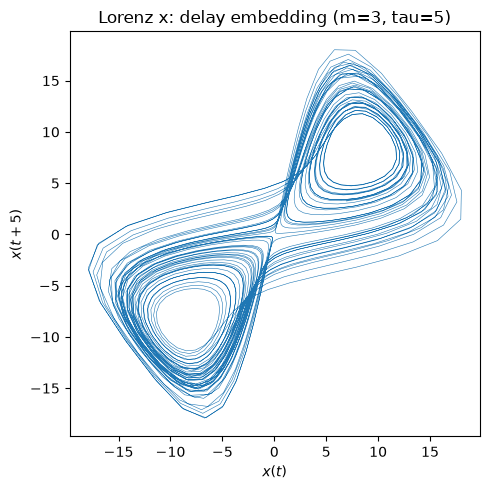

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(E[:, 0], E[:, 1], lw=0.4, color="C0")
ax.set_xlabel(r"$x(t)$")
ax.set_ylabel(rf"$x(t+{tau})$")
ax.set_title(f"Lorenz x: delay embedding (m={m}, tau={tau})")
plt.tight_layout()
plt.show()

## 2. `mixed_embedding` — multivariate embedding

Each variable gets its own embedding dimension and delay; all rows
share the same base index.  This is the natural choice when different
components need different reconstruction parameters.

Here we embed the Lorenz `x` and `y` components with `m_x = 2,
tau_x = 5` and `m_y = 3, tau_y = 2`.

In [4]:
y = data[:, 1]
E_mix = mixed_embedding(
    series_list=[x, y],
    dims=[2, 3],
    delays=[5, 2],
)
print(f"mixed embedding shape: {E_mix.shape} (expected (n, {2 + 3}))")
print("  x block columns 0:2, y block columns 2:5")
print("first 2 rows:")
print(E_mix[:2])

mixed embedding shape: (1995, 5) (expected (n, 5))
  x block columns 0:2, y block columns 2:5
first 2 rows:
[[ -2.96053571  -6.9388058   -4.11505431  -6.21133433  -9.38097603]
 [ -3.38334547  -8.38966866  -5.05113735  -7.64209864 -11.40206478]]


### 2-D projection

The first two columns of the mixed embedding give an `(x(t),
x(t + tau_x))` projection that recovers the butterfly structure:

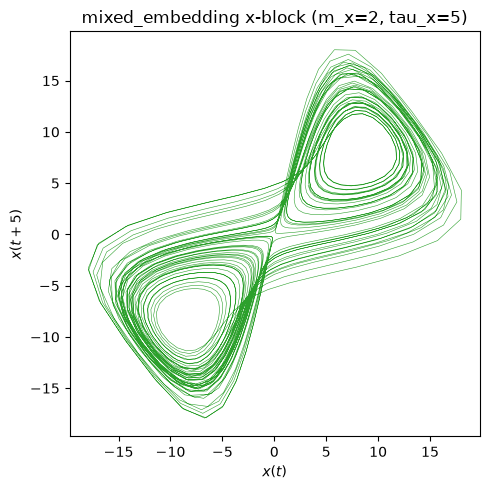

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(E_mix[:, 0], E_mix[:, 1], lw=0.4, color="C2")
ax.set_xlabel(r"$x(t)$")
ax.set_ylabel(rf"$x(t+{5})$")
ax.set_title("mixed_embedding x-block (m_x=2, tau_x=5)")
plt.tight_layout()
plt.show()

## 3. `lag_block_delay_embed` — interleaved column order

Build the embedding matrix in the interleaved column order: column
`k * n_vars + c` holds component `c` at delay index `k`.  The input is
`(n_times, n_vars)`.  This is the function used internally by
`nolitisea.dimension.d2`.

We embed the full 3-D Lorenz trajectory with `embed=4, delay=5`.

In [6]:
embed, delay = 4, 5
E_lag = lag_block_delay_embed(data, embed=embed, delay=delay)
n_vars = data.shape[1]
print(f"input shape:  {data.shape} (n_times, n_vars)")
print(f"output shape: {E_lag.shape} (expected (n, {n_vars * embed}))")
print("column order: " + ", ".join(
    f"col {k * n_vars + c} = x_{c}(t-{k * delay})"
    for k in range(embed) for c in range(n_vars)
))

input shape:  (2000, 3) (n_times, n_vars)
output shape: (1985, 12) (expected (n, 12))
column order: col 0 = x_0(t-0), col 1 = x_1(t-0), col 2 = x_2(t-0), col 3 = x_0(t-5), col 4 = x_1(t-5), col 5 = x_2(t-5), col 6 = x_0(t-10), col 7 = x_1(t-10), col 8 = x_2(t-10), col 9 = x_0(t-15), col 10 = x_1(t-15), col 11 = x_2(t-15)


### 2-D projection

The first two columns (one delay step per component) reconstruct the
state at the base time; plotting them recovers the Lorenz butterfly:

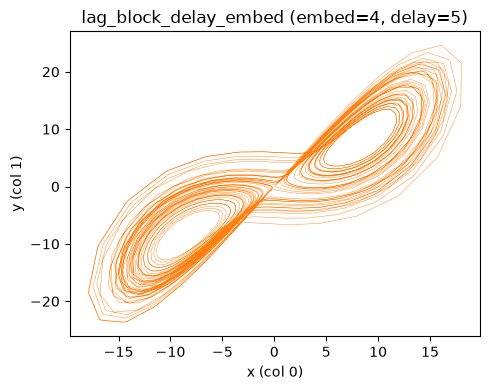

In [7]:
# The first 4 columns (one delay step per component) reconstruct the
# state at the base time; plotting the first two of them recovers the
# Lorenz butterfly.
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(E_lag[:, 0], E_lag[:, 1], lw=0.3, color="C1")
ax.set_xlabel("x (col 0)")
ax.set_ylabel("y (col 1)")
ax.set_title(f"lag_block_delay_embed (embed={embed}, delay={delay})")
plt.tight_layout()
plt.show()

## 4. `delay_vectors` — multivariate delay vectors

Input is a 1-D array or a 2-D array of shape `(n_vars, n_times)`.
Per-variable dimensions are given by `dims`; per-coordinate increments
by `increments` (which overrides `delay`).  Row `r` is anchored at the
base time `r + max_offset` and looks *backward* — the C-program
output layout (`-F` / `-d` / `-D` semantics).

### 4a. Univariate, default parameters

With `embdim=3, delay=5` the layout matches `delay_embedding` but
with the reversed (backward-looking) anchor.

In [8]:
E_dv = delay_vectors(x, embdim=3, delay=5)
print(f"delay_vectors shape: {E_dv.shape}")
print("first 3 rows:")
print(E_dv[:3])
# Backward anchor: row 0 corresponds to base time max_offset = 2*5 = 10
print("manual check (row 0):", x[[10, 5, 0]], "==", E_dv[0], "?",
      np.allclose(E_dv[0], x[[10, 5, 0]]))

delay_vectors shape: (1990, 3)
first 3 rows:
[[-14.1141943   -6.9388058   -2.96053571]
 [-14.15633599  -8.38966866  -3.38334547]
 [-13.23121112 -10.02987365  -3.96841082]]
manual check (row 0): [-14.1141943   -6.9388058   -2.96053571] == [-14.1141943   -6.9388058   -2.96053571] ? True


### 4b. Multivariate with per-variable `dims`

Embed the 3-D Lorenz trajectory `(x, y, z)` with `dims=[2, 2, 1]`
and a common `delay=4`.  The output has `sum(dims) = 5` columns.

In [9]:
# delay_vectors expects shape (n_vars, n_times) for multivariate input.
series_2d = data.T  # shape (3, n_times)
E_mv = delay_vectors(series_2d, dims=[2, 2, 1], delay=4)
print(f"multivariate delay_vectors shape: {E_mv.shape} (expected (n, 5))")
print("column blocks: x[0:2], y[2:4], z[4:5]")
print("first 2 rows:")
print(E_mv[:2])

multivariate delay_vectors shape: (1996, 5) (expected (n, 5))
column blocks: x[0:2], y[2:4], z[4:5]
first 2 rows:
[[ -5.72188712  -2.96053571  -9.38097603  -4.11505431  15.37441441]
 [ -6.9388058   -3.38334547 -11.40206478  -5.05113735  16.08822047]]


### 4c. Per-coordinate `increments`

When the delays between successive coordinates should differ, pass
`increments` (one value per extra coordinate).  Here we keep the
univariate `x` with `dims=[4]` and increments `[1, 3, 2]`, so the
cumulative offsets are `[0, 1, 4, 6]`.

In [10]:
E_inc = delay_vectors(x, dims=[4], increments=[1, 3, 2])
print(f"incremental embedding shape: {E_inc.shape}")
print("expected offsets: [0, 1, 4, 6]")
# row 0 is anchored at base time 6; columns are x[6], x[5], x[2], x[0]
print("manual check (row 0):", x[[6, 5, 2, 0]], "==", E_inc[0], "?",
      np.allclose(E_inc[0], x[[6, 5, 2, 0]]))

incremental embedding shape: (1994, 4)
expected offsets: [0, 1, 4, 6]
manual check (row 0): [-8.38966866 -6.9388058  -3.96841082 -2.96053571] == [-8.38966866 -6.9388058  -3.96841082 -2.96053571] ? True


## 5. `find_neighbors` — nearest-neighbour search

Locate the nearest neighbour of every point in a delay-coordinate
matrix using `scipy.spatial.cKDTree`.  The default metric is the
Chebyshev (max) norm, matching the TISEAN convention.  A Theiler
window excludes temporally adjacent points so that the neighbour is
geometrically — not temporally — close, which is essential for
Lyapunov-exponent and correlation-dimension estimates.

We reuse the `delay_embedding` matrix `E` (section 1) as the point
cloud and search for one nearest neighbour per point.

### 5a. Default search (Chebyshev, no Theiler window)

With the defaults `metric="chebyshev", theiler=0, maxnum=None` the
function auto-picks `maxnum = 2 * (theiler + 1) + 1 = 3` candidates
per query (the TISEAN heuristic) and keeps the first non-self,
non-Theiler neighbour.

In [11]:
idx, dist = find_neighbors(E)
print(f"E shape         : {E.shape}")
print(f"neighbour index: shape {idx.shape}, dtype {idx.dtype}")
print(f"distances      : shape {dist.shape}, min {dist.min():.4f}, max {dist.max():.4f}")
print(f"first 5 indices: {idx[:5]}")
print(f"first 5 dists  : {dist[:5]}")
# No point is its own neighbour.
assert np.all(idx != np.arange(len(idx)))
print("self-match check: OK (no point maps to itself)")

E shape         : (1990, 3)
neighbour index: shape (1990,), dtype int64
distances      : shape (1990,), min 0.0154, max 1.6609
first 5 indices: [514 745 619 620 621]
first 5 dists  : [0.18647909 0.13449118 0.12605272 0.14121974 0.1624354 ]
self-match check: OK (no point maps to itself)


### 5b. Theiler window

Setting `theiler` excludes every point with `|j - i| <= theiler` from
the neighbour search, so the returned indices must all lie outside the
window.  A typical choice for chaotic flows is one full orbit period.

In [12]:
theiler = 10
idx_t, dist_t = find_neighbors(E, theiler=theiler)
separations = np.abs(idx_t - np.arange(len(idx_t)))
print(f"theiler        : {theiler}")
print(f"min separation: {separations.min()} (must be > {theiler})")
print(f"max separation: {separations.max()}")
assert np.all(separations > theiler)
assert np.all(dist_t > 0)
print("Theiler check  : OK (all neighbours outside the window)")

theiler        : 10
min separation: 21 (must be > 10)
max separation: 1649
Theiler check  : OK (all neighbours outside the window)


### 5c. Comparing metrics

`find_neighbors` supports the Chebyshev (`"chebyshev"`), Euclidean
(`"euclidean"`) and Manhattan (`"cityblock"`) norms.  The neighbour
of a point generally differs across metrics; the distances do too.

In [13]:
results = {}
for metric in ["chebyshev", "euclidean", "cityblock"]:
    idx_m, dist_m = find_neighbors(E, metric=metric, theiler=5)
    results[metric] = (idx_m, dist_m)
    print(f"{metric:9s}: idx[:3]={idx_m[:3]}, dist[:3]={dist_m[:3]}")

# The three metrics typically disagree on at least some rows.
idx_che = results["chebyshev"][0]
idx_eu  = results["euclidean"][0]
idx_cb  = results["cityblock"][0]
n_match = np.sum((idx_che == idx_eu) & (idx_che == idx_cb))
print(f"\nrows where all three metrics agree: {n_match} / {len(idx_che)}")

chebyshev: idx[:3]=[514 745 619], dist[:3]=[0.18647909 0.13449118 0.12605272]
euclidean: idx[:3]=[514 618 619], dist[:3]=[0.21123626 0.17299818 0.16019832]
cityblock: idx[:3]=[514 618 746], dist[:3]=[0.2929009  0.24195275 0.23545341]

rows where all three metrics agree: 1595 / 1990


### Neighbour-distance distribution

A histogram of the Chebyshev neighbour distances shows the typical
spread of nearest-neighbour distances on the Lorenz embedding:

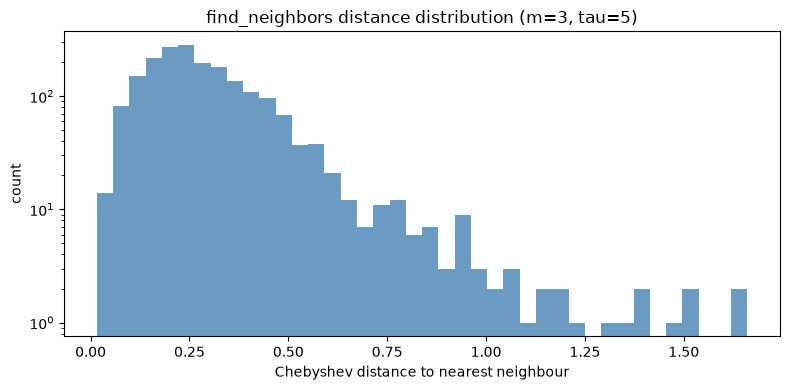

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(results["chebyshev"][1], bins=40, color="steelblue", alpha=0.8)
ax.set_xlabel("Chebyshev distance to nearest neighbour")
ax.set_ylabel("count")
ax.set_title(f"find_neighbors distance distribution (m={m}, tau={tau})")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

### Neighbour pairs on the attractor

Overlay the nearest-neighbour pairs (Chebyshev, `theiler=5`) on the
2-D projection of the embedding — each red segment links a point to
its neighbour.

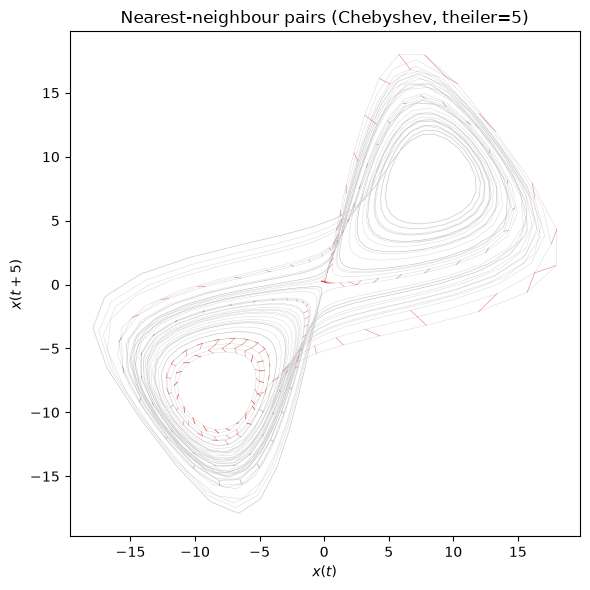

In [15]:
idx_p, _ = results["chebyshev"]
n_show = 200  # show first 200 pairs for clarity

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(E[:, 0], E[:, 1], lw=0.3, color="lightgray", zorder=1)
for i in range(n_show):
    j = idx_p[i]
    ax.plot([E[i, 0], E[j, 0]], [E[i, 1], E[j, 1]],
            color="C3", lw=0.4, alpha=0.6, zorder=2)
ax.set_xlabel(r"$x(t)$")
ax.set_ylabel(rf"$x(t+{tau})$")
ax.set_title("Nearest-neighbour pairs (Chebyshev, theiler=5)")
plt.tight_layout()
plt.show()

## Summary

The `nolitisea.core` module provides two complementary layers:

- **Embedding builders** (`nolitisea.core.embed`): `delay_embedding`,
  `mixed_embedding`, `lag_block_delay_embed` and `delay_vectors` turn
  one or more scalar series into a phase-space matrix.  They differ in
  the column layout and in whether the anchor looks forward (oldest
  sample) or backward (newest sample), reproducing the TISEAN `-m`,
  `-F`, `-d` and `-D` conventions.
- **Nearest-neighbour search** (`nolitisea.core.neighbors`):
  `find_neighbors` runs a vectorised `cKDTree` query with a Theiler
  window and a choice of Chebyshev / Euclidean / Manhattan metric.  It
  is the shared building block of the correlation-dimension,
  Lyapunov-exponent and recurrence routines.

Together they form the entry point of almost every phase-space method
in the package: embed first, then search for neighbours in the
reconstructed state space.